# Базовый блок. Обработка текстов с помощью нейронных сетей. ДЗ Lite (PyTorch)

## Классификация писателей — 9 моделей с различными гиперпараметрами

**Реализация на PyTorch**.

**Параметры предобработки:**
- Размер словаря (`VOCAB_SIZE`): **15 000**
- Ширина окна (`WIN_SIZE`): **1 000**
- Шаг окна (`WIN_HOP`): **100**

**Архитектуры нейросетей:**
- 4 модели Bag of Words — Dense сети на разреженной матрице частот слов
- 5 моделей Embedding — слой эмбеддинга + Flatten + Dense

Все модели используют:
- `nn.Sequential` или собственный класс наследующий `nn.Module`
- Один или несколько полносвязных слоёв `nn.Linear`
- Слои `nn.Dropout` и `nn.BatchNorm1d`
- Выходной слой с количеством нейронов = число классов

## Импорт библиотек

In [ ]:
# Работа с массивами данных
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Токенизация с помощью Keras
from tensorflow.keras.preprocessing.text import Tokenizer

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os
import time
import re
import pickle

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

# Определение устройства (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используем устройство: {device}')

# Фиксируем сид для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

Используем устройство: cuda


## Загрузка датасета и подготовка данных

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
# Распаковка архива
!unzip -qo writers.zip -d writers/
!ls writers

'(Булгаков) Обучающая_5 вместе.txt'
'(Булгаков) Тестовая_2 вместе.txt'
'(Клиффорд_Саймак) Обучающая_5 вместе.txt'
'(Клиффорд_Саймак) Тестовая_2 вместе.txt'
'(Макс Фрай) Обучающая_5 вместе.txt'
'(Макс Фрай) Тестовая_2 вместе.txt'
'(О. Генри) Обучающая_50 вместе.txt'
'(О. Генри) Тестовая_20 вместе.txt'
'(Рэй Брэдберри) Обучающая_22 вместе.txt'
'(Рэй Брэдберри) Тестовая_8 вместе.txt'
'(Стругацкие) Обучающая_5 вместе.txt'
'(Стругацкие) Тестовая_2 вместе.txt'


In [ ]:
# Настройка констант
FILE_DIR  = 'writers'
SIG_TRAIN = 'обучающая'
SIG_TEST  = 'тестовая'

In [ ]:
# Загрузка датасета
CLASS_LIST = []
text_train = []
text_test = []

for file_name in os.listdir(FILE_DIR):
    m = re.match(r'\((.+)\) (\S+)_', file_name)
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        if is_train or is_test:
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                text_train.append('')
                text_test.append('')

            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}"')
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                text = f.read()
            subset = text_train if is_train else text_test
            subset[cls] += ' ' + text.replace('\n', ' ')

CLASS_COUNT = len(CLASS_LIST)
print(f'\nКлассов: {CLASS_COUNT}')

Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай"
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри"
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак"
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри"
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри"
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков"
Добавление файла "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри"
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай"
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Тестовая_2 вместе.txt" в класс "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.t

## Параметры преобразования

In [ ]:
# Параметры преобразования
VOCAB_SIZE = 15000
WIN_SIZE   = 1000
WIN_HOP    = 100

## Токенизация и построение частотного словаря

Используем `Tokenizer` из Keras для совместимости с подходом. Сама модель и обучение — на PyTorch.

In [ ]:
class timex:
    def __enter__(self):
        self.t = time.time()
        return self
    def __exit__(self, type, value, traceback):
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

In [ ]:
# Токенизация
with timex():
    tokenizer = Tokenizer(num_words=VOCAB_SIZE,
                          filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ',
                          oov_token='неизвестное_слово',
                          char_level=False)
    tokenizer.fit_on_texts(text_train)
    items = list(tokenizer.word_index.items())

print('Размер словаря:', len(items))

Время обработки: 3.08 с
Размер словаря: 133070


In [ ]:
# Преобразование в последовательности индексов
with timex():
    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test = tokenizer.texts_to_sequences(text_test)

Время обработки: 4.44 с


## Формирование выборок методом скользящего окна

In [ ]:
def split_sequence(sequence, win_size, hop):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]

def vectorize_sequence(seq_list, win_size, hop):
    class_count = len(seq_list)
    x, y = [], []
    for cls in range(class_count):
        vectors = split_sequence(seq_list[cls], win_size, hop)
        x += vectors
        # В PyTorch метки классов идут просто как индексы (не one-hot)
        # Это эквивалент sparse_categorical_crossentropy в Keras
        y += [cls] * len(vectors)
    return np.array(x), np.array(y)

In [ ]:
# Формирование выборок
with timex():
    x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
    x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)
    print(f'Обучающая: {x_train.shape}, метки: {y_train.shape}')
    print(f'Тестовая: {x_test.shape}, метки: {y_test.shape}')

Обучающая: (17640, 1000), метки: (17640,)
Тестовая: (6686, 1000), метки: (6686,)
Время обработки: 2.63 с


In [ ]:
# Формирование Bag of Words матриц через токенизатор
with timex():
    x_train_01 = tokenizer.sequences_to_matrix(x_train.tolist())
    x_test_01 = tokenizer.sequences_to_matrix(x_test.tolist())
    print(f'BoW обучающая: {x_train_01.shape}')

BoW обучающая: (17640, 15000)
Время обработки: 8.93 с


## PyTorch Dataset и DataLoader

В PyTorch нет аналога `model.fit()` — данные подаём через `DataLoader`, который собирает батчи из объекта `Dataset`.

In [ ]:
# Конвертация в тензоры PyTorch
# Для BoW моделей
x_train_bow_t = torch.FloatTensor(x_train_01)
x_test_bow_t = torch.FloatTensor(x_test_01)

# Для Embedding моделей (целочисленные индексы слов)
x_train_emb_t = torch.LongTensor(x_train)
x_test_emb_t = torch.LongTensor(x_test)

# Метки классов (общие для обоих типов моделей)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

print('Тензоры готовы:')
print(f'  BoW обучающая: {x_train_bow_t.shape}, тип {x_train_bow_t.dtype}')
print(f'  Embedding обучающая: {x_train_emb_t.shape}, тип {x_train_emb_t.dtype}')
print(f'  Метки: {y_train_t.shape}, тип {y_train_t.dtype}')

Тензоры готовы:
  BoW обучающая: torch.Size([17640, 15000]), тип torch.float32
  Embedding обучающая: torch.Size([17640, 1000]), тип torch.int64
  Метки: torch.Size([17640]), тип torch.int64


In [ ]:
# DataLoader для BoW
BATCH_SIZE = 128

train_loader_bow = DataLoader(
    TensorDataset(x_train_bow_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_loader_bow = DataLoader(
    TensorDataset(x_test_bow_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# DataLoader для Embedding
train_loader_emb = DataLoader(
    TensorDataset(x_train_emb_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_loader_emb = DataLoader(
    TensorDataset(x_test_emb_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f'Батчей в обучающей BoW: {len(train_loader_bow)}')
print(f'Батчей в тестовой BoW: {len(test_loader_bow)}')

Батчей в обучающей BoW: 138
Батчей в тестовой BoW: 53


## Сервисные функции для обучения и оценки моделей

В PyTorch обучение пишется вручную: цикл по эпохам → цикл по батчам → forward → loss → backward → step.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    """Обучение модели PyTorch."""
    model = model.to(device)

    # Оптимизатор и функция потерь
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()  # включает softmax внутри себя

    # История метрик для графиков
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        # ===== ОБУЧЕНИЕ =====
        model.train()  # переводим модель в режим обучения (активирует Dropout, BN)
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()           # обнуляем градиенты
            outputs = model(x_batch)        # прямой проход
            loss = criterion(outputs, y_batch)  # вычисляем ошибку
            loss.backward()                 # обратное распространение
            optimizer.step()                # шаг оптимизатора

            train_loss += loss.item() * x_batch.size(0)
            _, predicted = outputs.max(1)
            train_total += y_batch.size(0)
            train_correct += predicted.eq(y_batch).sum().item()

        train_loss /= train_total
        train_acc = train_correct / train_total

        # ===== ВАЛИДАЦИЯ =====
        model.eval()  # режим оценки (Dropout/BN ведут себя иначе)
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # не считаем градиенты для экономии памяти
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item() * x_batch.size(0)
                _, predicted = outputs.max(1)
                val_total += y_batch.size(0)
                val_correct += predicted.eq(y_batch).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Сохраняем метрики
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f'Эпоха {epoch+1}/{epochs}: loss={train_loss:.4f}, acc={train_acc:.4f}, '
              f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')

    return history


def plot_history(history, title=''):
    """Графики обучения."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle(f'График обучения: {title}')

    ax1.plot(history['accuracy'], label='Обучающая выборка')
    ax1.plot(history['val_accuracy'], label='Проверочная выборка')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history['loss'], label='Обучающая выборка')
    ax2.plot(history['val_loss'], label='Проверочная выборка')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


def eval_model(model, val_loader, class_labels=CLASS_LIST, title='', figsize=(10, 10)):
    """Оценка модели + матрица ошибок."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            outputs = model(x_batch)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    cm = np.around(cm, 3)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'{title}: матрица ошибок', fontsize=16)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()
    plt.xlabel('Предсказанные классы', fontsize=14)
    plt.ylabel('Верные классы', fontsize=14)
    fig.autofmt_xdate(rotation=45)
    plt.show()

    print('-' * 80)
    print(f'Нейросеть: {title}')

    for cls in range(len(class_labels)):
        cls_pred = np.argmax(cm[cls])
        msg = 'ВЕРНО :-)' if cls_pred == cls else 'НЕВЕРНО :-('
        print(f'Класс: {class_labels[cls]:<20} {100*cm[cls, cls_pred]:3.0f}% сеть отнесла к классу '
              f'{class_labels[cls_pred]:<20} - {msg}')

    accuracy = 100. * cm.diagonal().mean()
    print(f'\nСредняя точность распознавания: {accuracy:.1f}%')
    return accuracy


def train_eval(model, train_loader, val_loader, title='', epochs=20):
    """Обучение + оценка с графиками."""
    print(f'\n{"="*80}\n{title}\n{"="*80}')
    print(model)

    history = train_model(model, train_loader, val_loader, epochs=epochs)
    plot_history(history, title=title)
    accuracy = eval_model(model, val_loader, title=title)
    return accuracy

results = {}

# 9 моделей с различными гиперпараметрами

Каждая модель — собственный класс наследующий `nn.Module`.
В `__init__` объявляем слои, в `forward` пишем прямой проход.

## Модель 1: BoW + Dense(200) + Dropout(0.25)


Модель 1: BoW Dense(200)
Model1_BoW(
  (fc1): Linear(in_features=15000, out_features=200, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (bn): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=6, bias=True)
)
Эпоха 1/20: loss=0.0532, acc=0.9893, val_loss=0.3564, val_acc=0.9064
Эпоха 2/20: loss=0.0011, acc=1.0000, val_loss=0.3246, val_acc=0.9110
Эпоха 3/20: loss=0.0005, acc=1.0000, val_loss=0.3077, val_acc=0.9124
Эпоха 4/20: loss=0.0003, acc=1.0000, val_loss=0.3229, val_acc=0.9002
Эпоха 5/20: loss=0.0002, acc=1.0000, val_loss=0.2999, val_acc=0.9106
Эпоха 6/20: loss=0.0001, acc=1.0000, val_loss=0.2963, val_acc=0.9118
Эпоха 7/20: loss=0.0001, acc=1.0000, val_loss=0.3049, val_acc=0.9068
Эпоха 8/20: loss=0.0001, acc=1.0000, val_loss=0.2944, val_acc=0.9077
Эпоха 9/20: loss=0.0001, acc=1.0000, val_loss=0.2963, val_acc=0.9086
Эпоха 10/20: loss=0.0001, acc=1.0000, val_loss=0.2847, val_acc=0.9088
Эпоха 11/20:

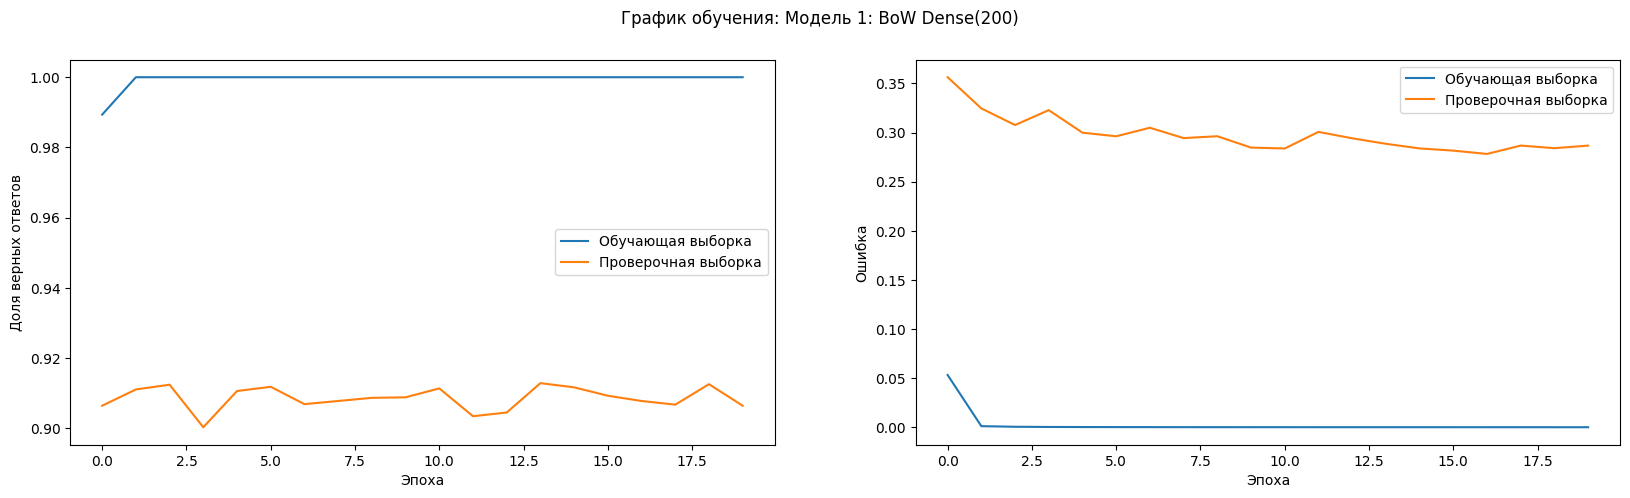

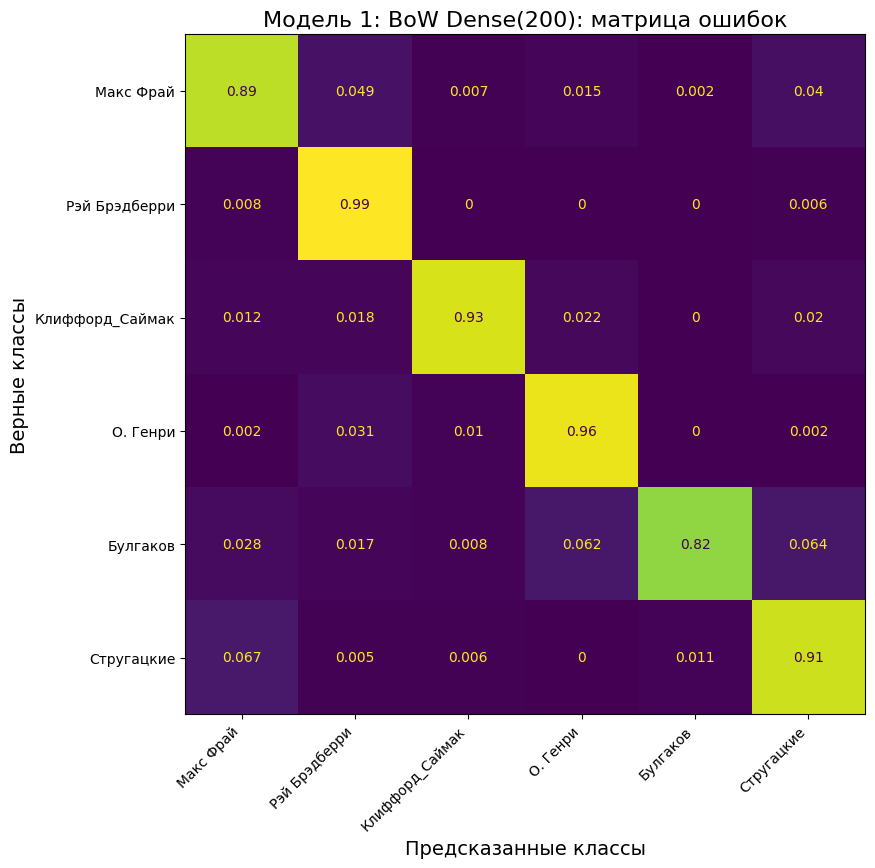

--------------------------------------------------------------------------------
Нейросеть: Модель 1: BoW Dense(200)
Класс: Макс Фрай             89% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         99% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       93% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: О. Генри              96% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              82% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            91% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 91.5%


In [ ]:
class Model1_BoW(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(VOCAB_SIZE, 200)
        self.dropout = nn.Dropout(0.25)
        self.bn = nn.BatchNorm1d(200)
        self.fc2 = nn.Linear(200, CLASS_COUNT)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.bn(x)
        x = self.fc2(x)
        return x

model_1 = Model1_BoW()
acc_1 = train_eval(model_1, train_loader_bow, test_loader_bow,
                   title='Модель 1: BoW Dense(200)', epochs=20)
results['Модель 1: BoW Dense(200)'] = acc_1

## Модель 2: BoW + Dense(400) + Dropout(0.4)


Модель 2: BoW Dense(400)
Model2_BoW(
  (fc1): Linear(in_features=15000, out_features=400, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (bn): BatchNorm1d(400, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=400, out_features=6, bias=True)
)
Эпоха 1/20: loss=0.0459, acc=0.9885, val_loss=0.3327, val_acc=0.8980
Эпоха 2/20: loss=0.0006, acc=1.0000, val_loss=0.3161, val_acc=0.9023
Эпоха 3/20: loss=0.0003, acc=1.0000, val_loss=0.3170, val_acc=0.8966
Эпоха 4/20: loss=0.0002, acc=1.0000, val_loss=0.3068, val_acc=0.9007
Эпоха 5/20: loss=0.0001, acc=1.0000, val_loss=0.2974, val_acc=0.9034
Эпоха 6/20: loss=0.0001, acc=1.0000, val_loss=0.3013, val_acc=0.9020
Эпоха 7/20: loss=0.0001, acc=1.0000, val_loss=0.2986, val_acc=0.9038
Эпоха 8/20: loss=0.0000, acc=1.0000, val_loss=0.2943, val_acc=0.9035
Эпоха 9/20: loss=0.0000, acc=1.0000, val_loss=0.2921, val_acc=0.9013
Эпоха 10/20: loss=0.0000, acc=1.0000, val_loss=0.2895, val_acc=0.9034
Эпоха 11/20: 

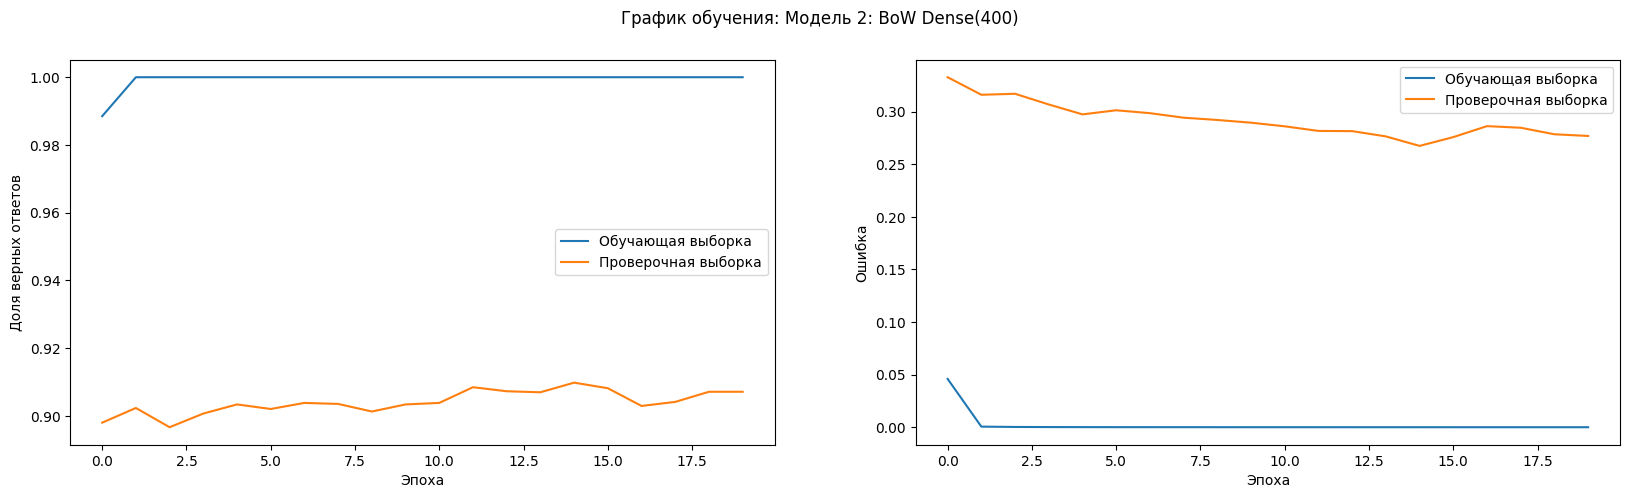

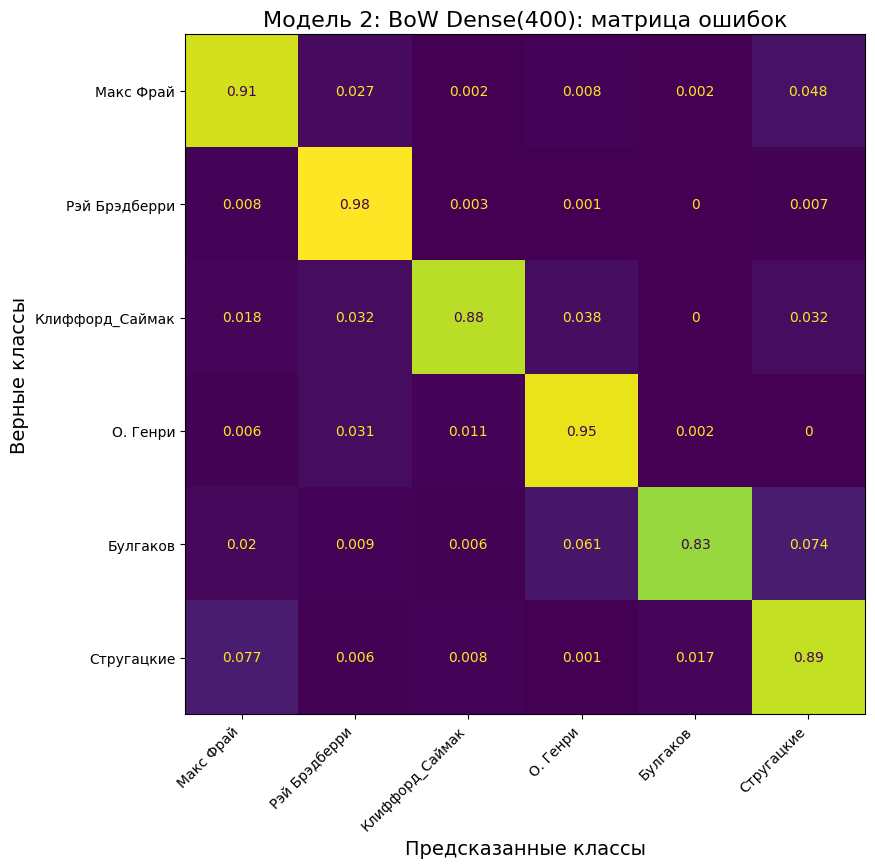

--------------------------------------------------------------------------------
Нейросеть: Модель 2: BoW Dense(400)
Класс: Макс Фрай             91% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         98% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       88% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: О. Генри              95% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              83% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            89% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 90.7%


In [ ]:
class Model2_BoW(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(VOCAB_SIZE, 400)
        self.dropout = nn.Dropout(0.4)
        self.bn = nn.BatchNorm1d(400)
        self.fc2 = nn.Linear(400, CLASS_COUNT)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.bn(x)
        x = self.fc2(x)
        return x

model_2 = Model2_BoW()
acc_2 = train_eval(model_2, train_loader_bow, test_loader_bow,
                   title='Модель 2: BoW Dense(400)', epochs=20)
results['Модель 2: BoW Dense(400)'] = acc_2

## Модель 3: BoW + Dense(300→100)


Модель 3: BoW Dense(300→100)
Model3_BoW(
  (fc1): Linear(in_features=15000, out_features=300, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (bn1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (bn2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=100, out_features=6, bias=True)
)
Эпоха 1/20: loss=0.1150, acc=0.9821, val_loss=0.3346, val_acc=0.9025
Эпоха 2/20: loss=0.0054, acc=1.0000, val_loss=0.3147, val_acc=0.9016
Эпоха 3/20: loss=0.0024, acc=1.0000, val_loss=0.2852, val_acc=0.9100
Эпоха 4/20: loss=0.0014, acc=1.0000, val_loss=0.2857, val_acc=0.9061
Эпоха 5/20: loss=0.0009, acc=1.0000, val_loss=0.2905, val_acc=0.9046
Эпоха 6/20: loss=0.0007, acc=1.0000, val_loss=0.2788, val_acc=0.9091
Эпоха 7/20: loss=0.0005, acc=1.0000, val_loss=0.2705, val_acc=0.9122
Эпоха 8/20: loss=0.

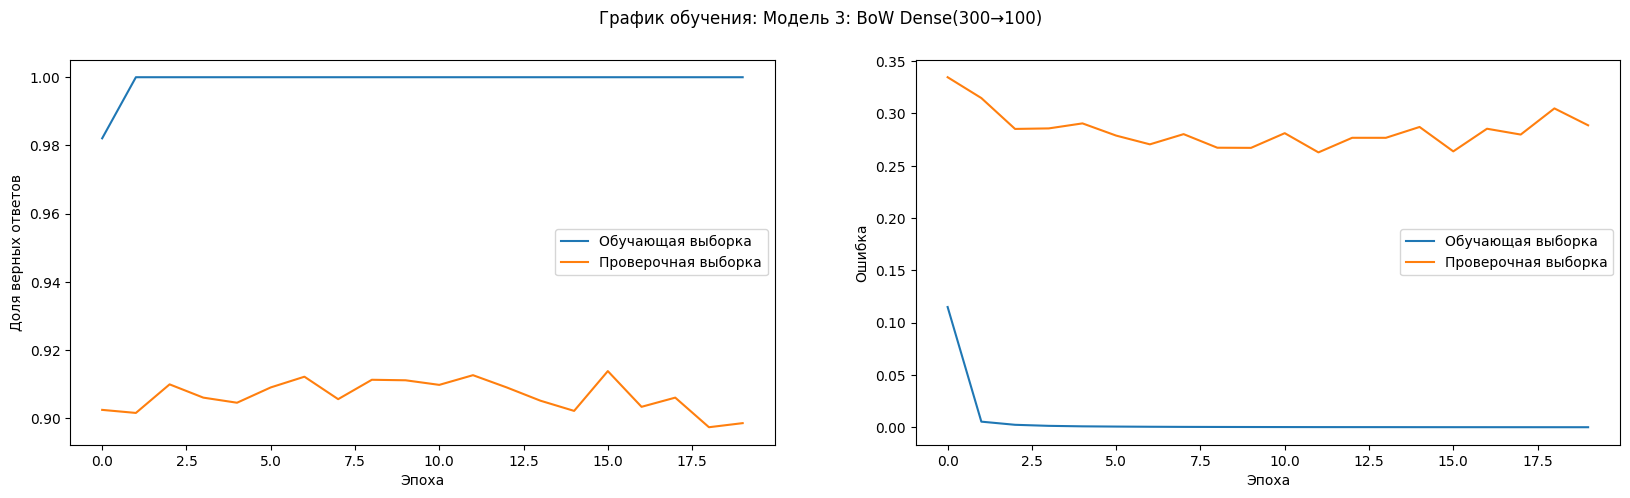

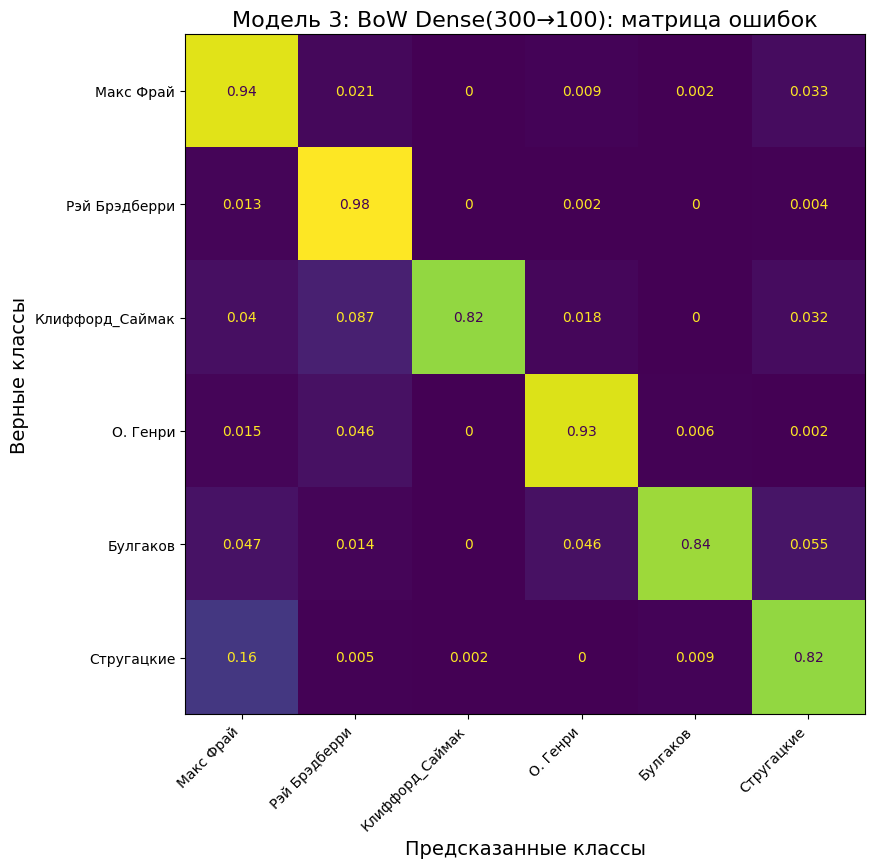

--------------------------------------------------------------------------------
Нейросеть: Модель 3: BoW Dense(300→100)
Класс: Макс Фрай             94% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         98% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       82% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: О. Генри              93% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              84% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            82% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 88.9%


In [ ]:
class Model3_BoW(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(VOCAB_SIZE, 300)
        self.dropout1 = nn.Dropout(0.3)
        self.bn1 = nn.BatchNorm1d(300)
        self.fc2 = nn.Linear(300, 100)
        self.dropout2 = nn.Dropout(0.3)
        self.bn2 = nn.BatchNorm1d(100)
        self.fc3 = nn.Linear(100, CLASS_COUNT)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.bn1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.bn2(x)
        x = self.fc3(x)
        return x

model_3 = Model3_BoW()
acc_3 = train_eval(model_3, train_loader_bow, test_loader_bow,
                   title='Модель 3: BoW Dense(300→100)', epochs=20)
results['Модель 3: BoW Dense(300→100)'] = acc_3

## Модель 4: BoW + Dense(500→200→50)


Модель 4: BoW Dense(500→200→50)
Model4_BoW(
  (fc1): Linear(in_features=15000, out_features=500, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (bn1): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=500, out_features=200, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (bn2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=200, out_features=50, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (bn3): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=50, out_features=6, bias=True)
)
Эпоха 1/20: loss=0.1843, acc=0.9722, val_loss=0.3277, val_acc=0.9095
Эпоха 2/20: loss=0.0137, acc=1.0000, val_loss=0.2897, val_acc=0.9118
Эпоха 3/20: loss=0.0060, acc=1.0000, val_loss=0.2712, val_acc=0.9137
Эпоха 4/20: loss=0.0034, acc=1.0000, val_loss=0.2535, val_acc=0.9192
Эпоха 5/20: loss=0.0023, acc=1

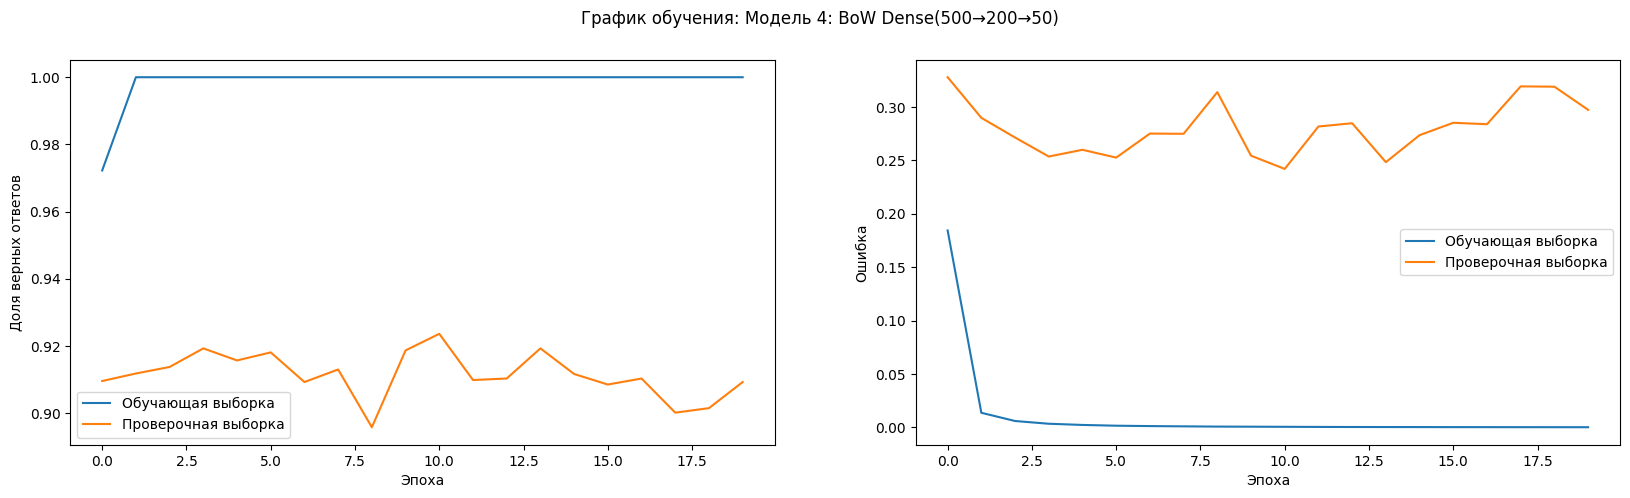

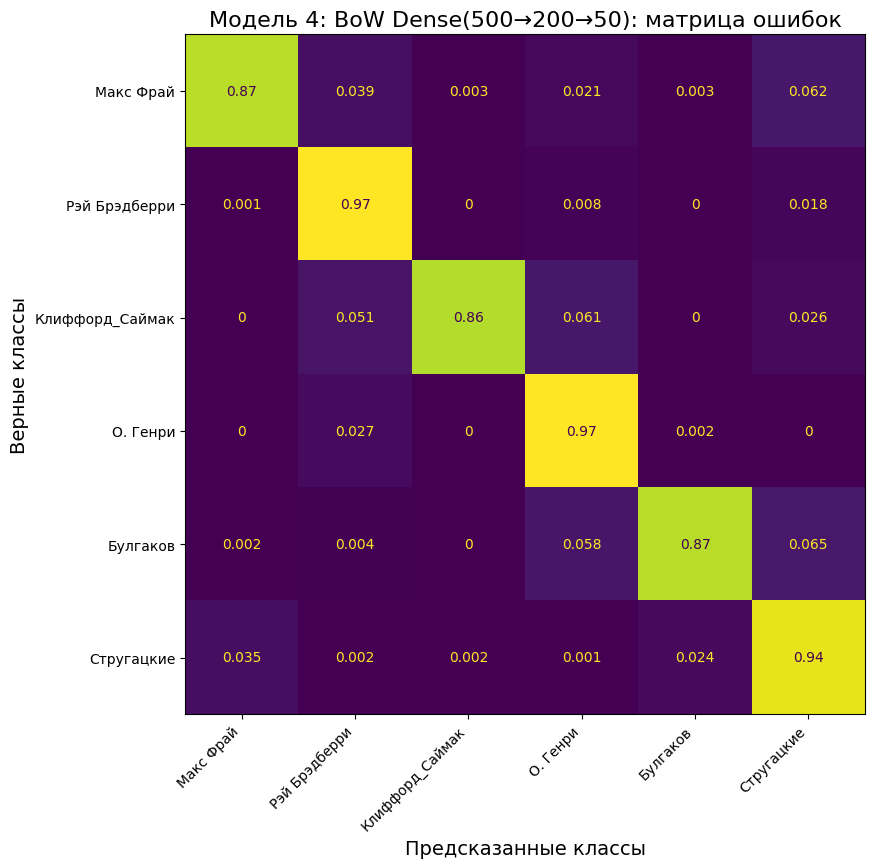

--------------------------------------------------------------------------------
Нейросеть: Модель 4: BoW Dense(500→200→50)
Класс: Макс Фрай             87% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         97% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       86% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: О. Генри              97% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              87% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            94% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 91.4%


In [ ]:
class Model4_BoW(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(VOCAB_SIZE, 500)
        self.dropout1 = nn.Dropout(0.3)
        self.bn1 = nn.BatchNorm1d(500)
        self.fc2 = nn.Linear(500, 200)
        self.dropout2 = nn.Dropout(0.3)
        self.bn2 = nn.BatchNorm1d(200)
        self.fc3 = nn.Linear(200, 50)
        self.dropout3 = nn.Dropout(0.2)
        self.bn3 = nn.BatchNorm1d(50)
        self.fc4 = nn.Linear(50, CLASS_COUNT)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.bn1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.bn2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.bn3(x)
        x = self.fc4(x)
        return x

model_4 = Model4_BoW()
acc_4 = train_eval(model_4, train_loader_bow, test_loader_bow,
                   title='Модель 4: BoW Dense(500→200→50)', epochs=20)
results['Модель 4: BoW Dense(500→200→50)'] = acc_4

## Модель 5: Embedding(20) + Flatten + Dense(200)

В PyTorch нет отдельного слоя `Flatten` для последовательностей — используем `x.view(batch, -1)` или `nn.Flatten()`.

`SpatialDropout1D` из Keras — это `nn.Dropout2d` в PyTorch (зануляет случайные каналы целиком, а не отдельные элементы).


Модель 5: Embedding(20) + Flatten
Model5_Emb(
  (embedding): Embedding(15000, 20)
  (spatial_dropout): Dropout2d(p=0.2, inplace=False)
  (bn1): BatchNorm1d(20000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=20000, out_features=200, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (bn2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=6, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Эпоха 1/15: loss=1.5233, acc=0.4159, val_loss=1.6227, val_acc=0.3576
Эпоха 2/15: loss=0.5949, acc=0.8115, val_loss=1.7766, val_acc=0.3637
Эпоха 3/15: loss=0.1810, acc=0.9549, val_loss=1.9155, val_acc=0.3800
Эпоха 4/15: loss=0.0691, acc=0.9860, val_loss=2.0057, val_acc=0.4028
Эпоха 5/15: loss=0.0395, acc=0.9926, val_loss=2.1208, val_acc=0.4010
Эпоха 6/15: loss=0.0292, acc=0.9941, val_loss=2.1933, val_acc=0.4044
Эпоха 7/15: loss=0.0258, acc=0.9944, val_loss=2.2830, val_acc=0.4019
Эпоха 8/15: loss=0.0232, acc=0.9948, val_loss=2.2792, val_acc=0.4119
Эпоха 9/15: loss=0.0233, acc=0.9938, val_loss=2.2942, val_acc=0.4224
Эпоха 10/15: loss=0.0247, acc=0.9925, val_loss=2.3770, val_acc=0.4168
Эпоха 11/15: loss=0.0232, acc=0.9931, val_loss=2.3155, val_acc=0.4230
Эпоха 12/15: loss=0.0212, acc=0.9941, val_loss=2.3167, val_acc=0.4251
Эпоха 13/15: loss=0.0225, acc=0.9937, val_loss=2.3546, val_acc=0.4290
Эпоха 14/15: loss=0.0229, acc=0.9927, val_loss=2.3192, val_acc=0.4349
Эпоха 15/15: loss=0.0198, acc

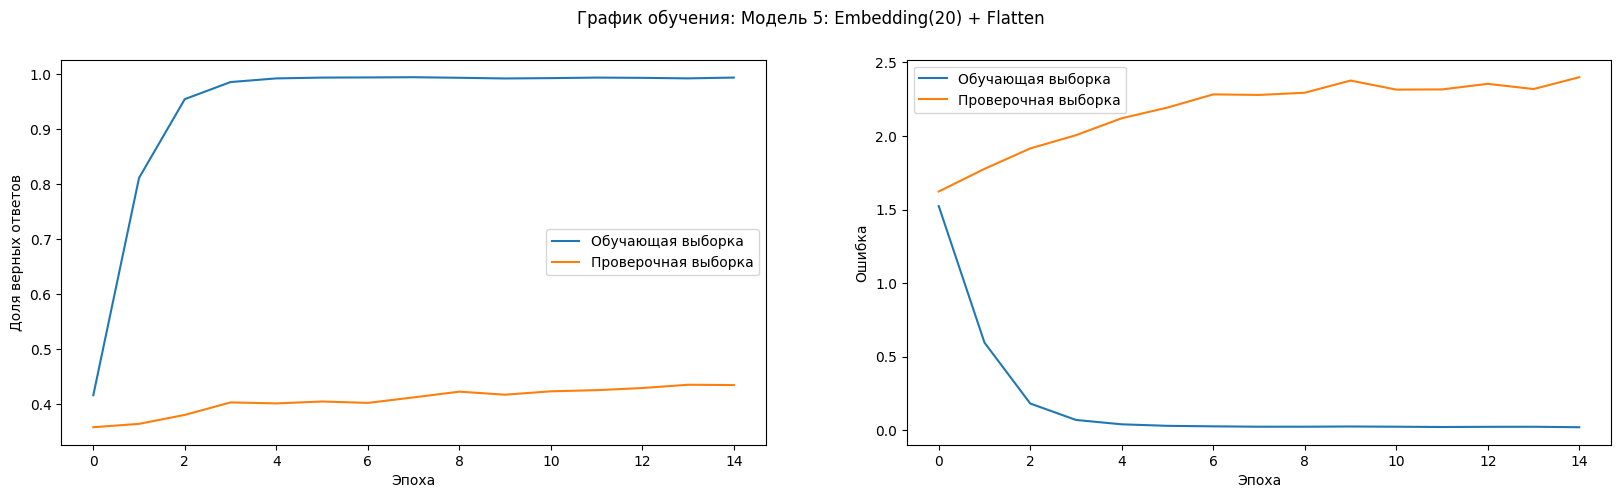

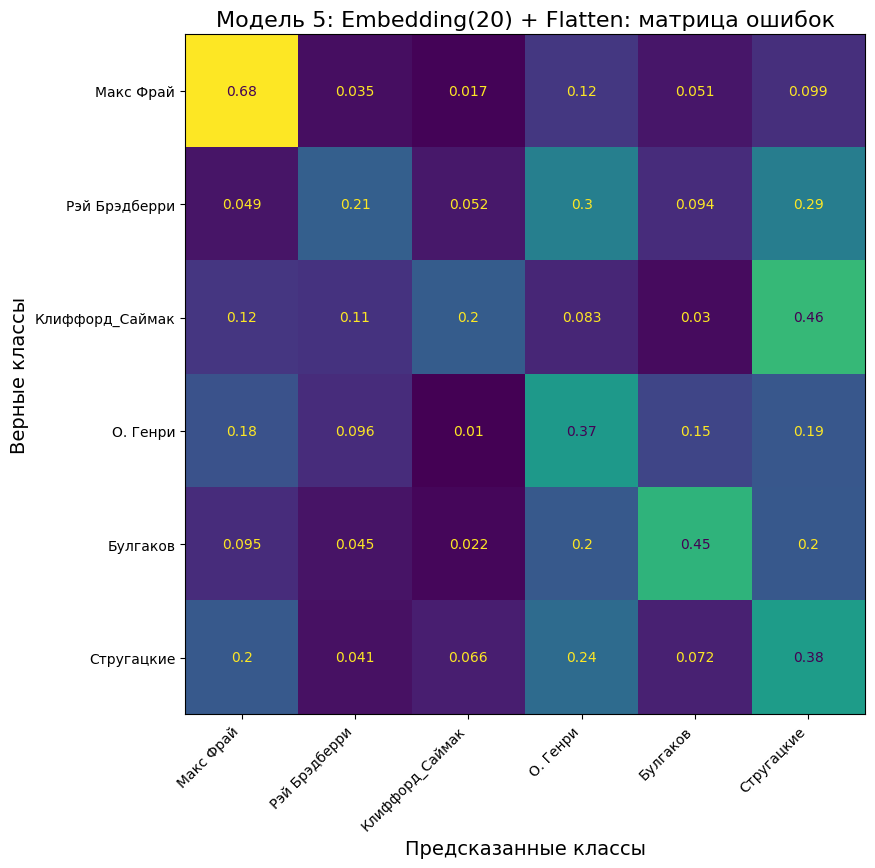

--------------------------------------------------------------------------------
Нейросеть: Модель 5: Embedding(20) + Flatten
Класс: Макс Фрай             68% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         30% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       46% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: О. Генри              37% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              45% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            38% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 38.2%


In [ ]:
class Model5_Emb(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, 20)
        # SpatialDropout1D: используем Dropout2d с правильной размерностью
        self.spatial_dropout = nn.Dropout2d(0.2)
        self.bn1 = nn.BatchNorm1d(WIN_SIZE * 20)
        self.fc1 = nn.Linear(WIN_SIZE * 20, 200)
        self.dropout = nn.Dropout(0.2)
        self.bn2 = nn.BatchNorm1d(200)
        self.fc2 = nn.Linear(200, CLASS_COUNT)

    def forward(self, x):
        # x: (batch, seq_len) — индексы слов
        x = self.embedding(x)  # (batch, seq_len, embed_dim)
        # SpatialDropout1D: переставляем оси для Dropout2d
        x = x.permute(0, 2, 1)  # (batch, embed_dim, seq_len)
        x = self.spatial_dropout(x)
        x = x.permute(0, 2, 1)  # обратно (batch, seq_len, embed_dim)
        # Flatten
        x = x.reshape(x.size(0), -1)  # (batch, seq_len * embed_dim)
        x = self.bn1(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.bn2(x)
        x = self.fc2(x)
        return x

model_5 = Model5_Emb()
acc_5 = train_eval(model_5, train_loader_emb, test_loader_emb,
                   title='Модель 5: Embedding(20) + Flatten', epochs=15)
results['Модель 5: Embedding(20) + Flatten'] = acc_5

## Модель 6: Embedding(50) + Flatten + Dense(300)


Модель 6: Embedding(50) + Flatten
Model6_Emb(
  (embedding): Embedding(15000, 50)
  (spatial_dropout): Dropout2d(p=0.3, inplace=False)
  (bn1): BatchNorm1d(50000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=50000, out_features=300, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (bn2): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=300, out_features=6, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Эпоха 1/15: loss=1.4769, acc=0.4420, val_loss=1.5830, val_acc=0.3803
Эпоха 2/15: loss=0.5059, acc=0.8466, val_loss=1.7233, val_acc=0.3866
Эпоха 3/15: loss=0.1171, acc=0.9745, val_loss=1.8139, val_acc=0.4040
Эпоха 4/15: loss=0.0430, acc=0.9927, val_loss=1.8597, val_acc=0.4071
Эпоха 5/15: loss=0.0251, acc=0.9954, val_loss=1.9252, val_acc=0.4137
Эпоха 6/15: loss=0.0184, acc=0.9963, val_loss=2.0149, val_acc=0.4004
Эпоха 7/15: loss=0.0153, acc=0.9968, val_loss=2.0412, val_acc=0.4164
Эпоха 8/15: loss=0.0126, acc=0.9978, val_loss=2.1310, val_acc=0.4174
Эпоха 9/15: loss=0.0118, acc=0.9978, val_loss=2.1377, val_acc=0.4251
Эпоха 10/15: loss=0.0081, acc=0.9991, val_loss=2.1920, val_acc=0.4287
Эпоха 11/15: loss=0.0092, acc=0.9979, val_loss=2.1874, val_acc=0.4258
Эпоха 12/15: loss=0.0096, acc=0.9978, val_loss=2.2475, val_acc=0.4230
Эпоха 13/15: loss=0.0106, acc=0.9975, val_loss=2.1268, val_acc=0.4319
Эпоха 14/15: loss=0.0122, acc=0.9968, val_loss=2.1132, val_acc=0.4412
Эпоха 15/15: loss=0.0123, acc

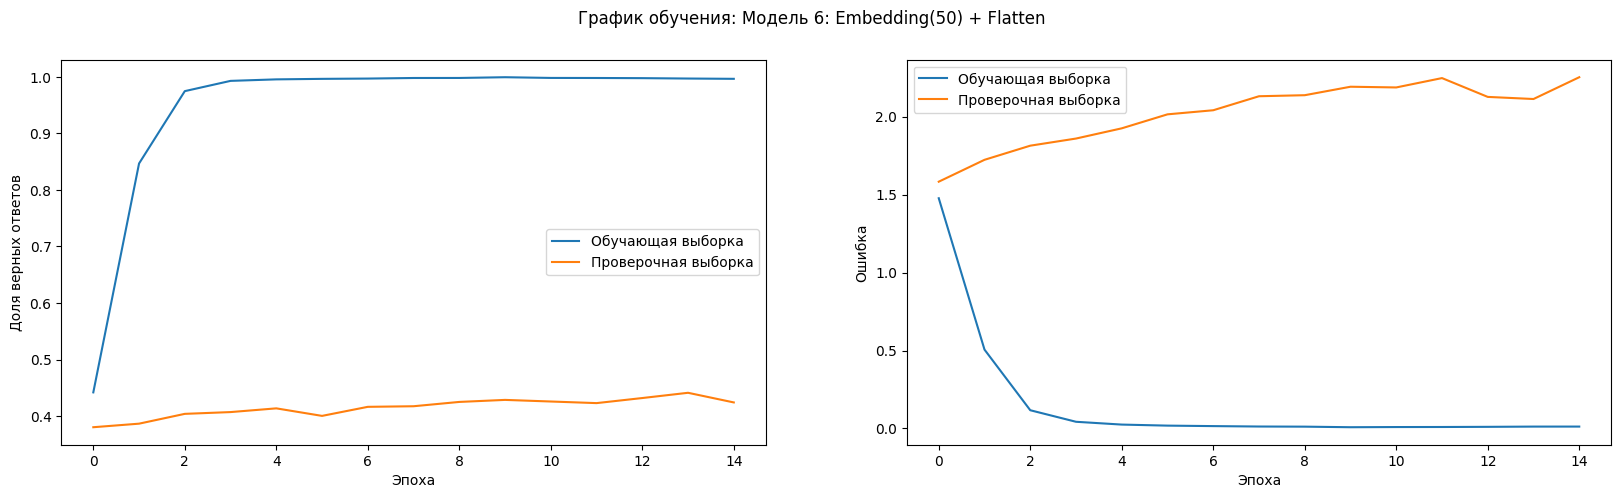

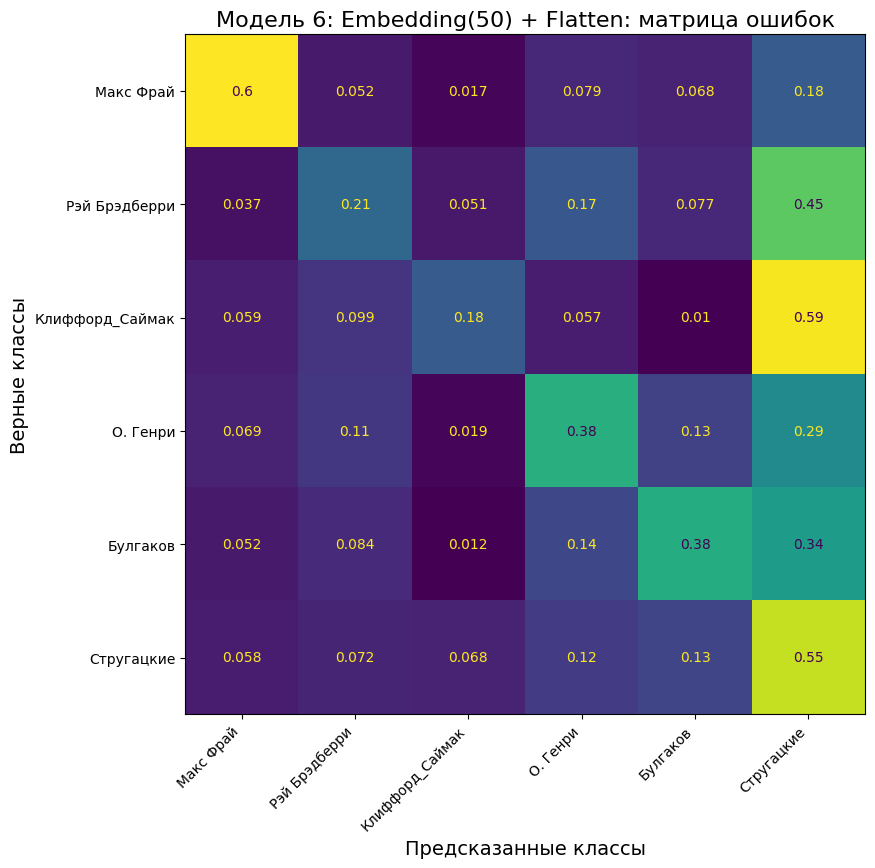

--------------------------------------------------------------------------------
Нейросеть: Модель 6: Embedding(50) + Flatten
Класс: Макс Фрай             60% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         45% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       60% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: О. Генри              38% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              38% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            55% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 38.4%


In [ ]:
class Model6_Emb(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, 50)
        self.spatial_dropout = nn.Dropout2d(0.3)
        self.bn1 = nn.BatchNorm1d(WIN_SIZE * 50)
        self.fc1 = nn.Linear(WIN_SIZE * 50, 300)
        self.dropout = nn.Dropout(0.3)
        self.bn2 = nn.BatchNorm1d(300)
        self.fc2 = nn.Linear(300, CLASS_COUNT)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.spatial_dropout(x)
        x = x.permute(0, 2, 1)
        x = x.reshape(x.size(0), -1)
        x = self.bn1(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.bn2(x)
        x = self.fc2(x)
        return x

model_6 = Model6_Emb()
acc_6 = train_eval(model_6, train_loader_emb, test_loader_emb,
                   title='Модель 6: Embedding(50) + Flatten', epochs=15)
results['Модель 6: Embedding(50) + Flatten'] = acc_6

## Модель 7: Embedding(100) + Flatten + Dense(200→100)


Модель 7: Embedding(100) + Flatten
Model7_Emb(
  (embedding): Embedding(15000, 100)
  (spatial_dropout): Dropout2d(p=0.2, inplace=False)
  (bn1): BatchNorm1d(100000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=100000, out_features=200, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (bn2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=100, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (bn3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=100, out_features=6, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Эпоха 1/15: loss=1.3286, acc=0.4836, val_loss=1.5208, val_acc=0.3636
Эпоха 2/15: loss=0.4191, acc=0.8725, val_loss=1.7470, val_acc=0.3975
Эпоха 3/15: loss=0.0914, acc=0.9784, val_loss=1.8256, val_acc=0.4270
Эпоха 4/15: loss=0.0309, acc=0.9946, val_loss=1.9269, val_acc=0.4293
Эпоха 5/15: loss=0.0193, acc=0.9964, val_loss=2.0449, val_acc=0.4303
Эпоха 6/15: loss=0.0116, acc=0.9978, val_loss=2.0227, val_acc=0.4391
Эпоха 7/15: loss=0.0100, acc=0.9979, val_loss=2.2965, val_acc=0.4155
Эпоха 8/15: loss=0.0098, acc=0.9977, val_loss=2.2148, val_acc=0.4300
Эпоха 9/15: loss=0.0085, acc=0.9981, val_loss=2.2906, val_acc=0.4302
Эпоха 10/15: loss=0.0091, acc=0.9976, val_loss=2.2742, val_acc=0.4399
Эпоха 11/15: loss=0.0094, acc=0.9974, val_loss=2.5689, val_acc=0.4222
Эпоха 12/15: loss=0.0136, acc=0.9959, val_loss=2.3626, val_acc=0.4433
Эпоха 13/15: loss=0.0163, acc=0.9946, val_loss=2.3807, val_acc=0.4533
Эпоха 14/15: loss=0.0195, acc=0.9934, val_loss=2.2976, val_acc=0.4554
Эпоха 15/15: loss=0.0182, acc

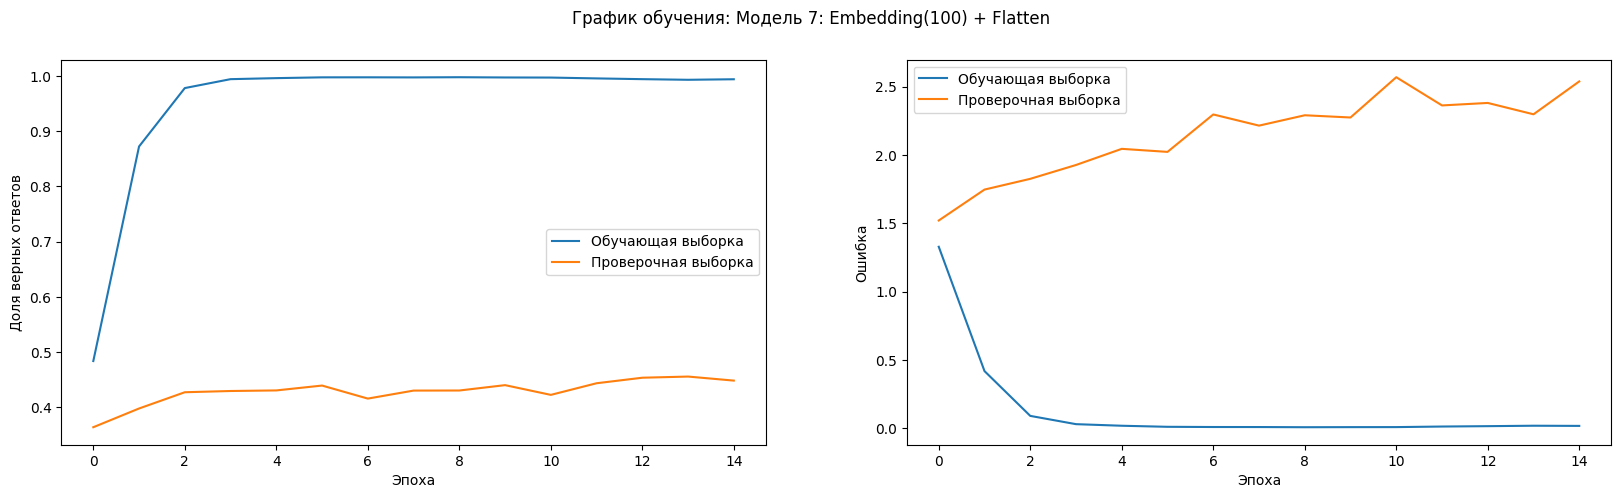

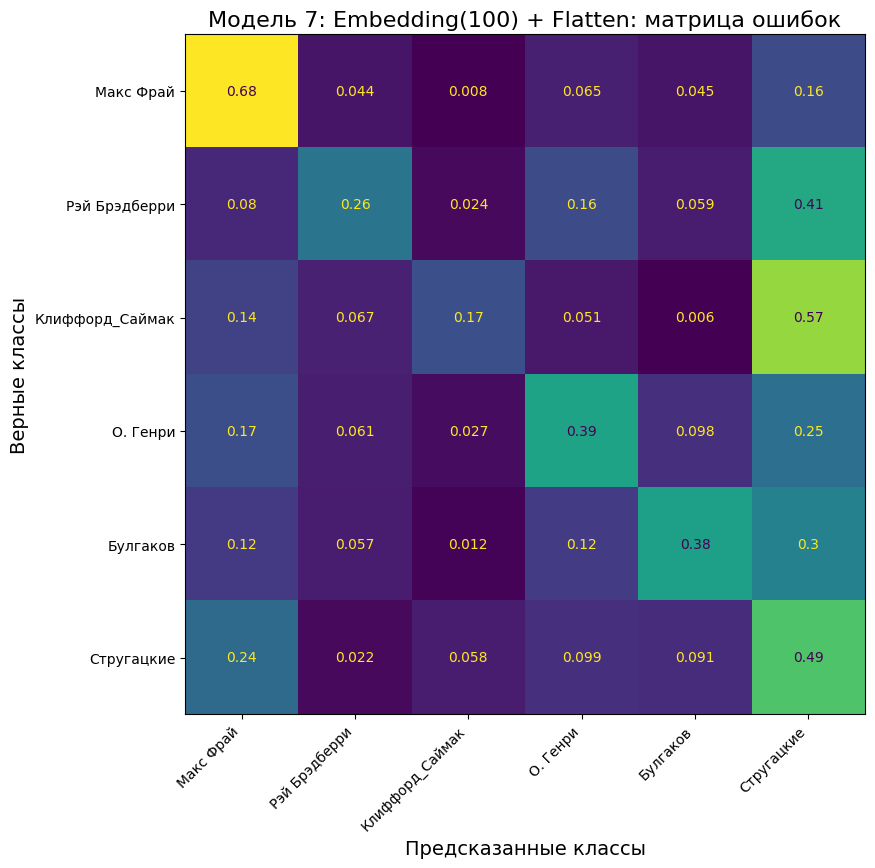

--------------------------------------------------------------------------------
Нейросеть: Модель 7: Embedding(100) + Flatten
Класс: Макс Фрай             68% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         41% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       57% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: О. Генри              39% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              38% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            49% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 39.6%


In [ ]:
class Model7_Emb(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, 100)
        self.spatial_dropout = nn.Dropout2d(0.2)
        self.bn1 = nn.BatchNorm1d(WIN_SIZE * 100)
        self.fc1 = nn.Linear(WIN_SIZE * 100, 200)
        self.dropout1 = nn.Dropout(0.3)
        self.bn2 = nn.BatchNorm1d(200)
        self.fc2 = nn.Linear(200, 100)
        self.dropout2 = nn.Dropout(0.2)
        self.bn3 = nn.BatchNorm1d(100)
        self.fc3 = nn.Linear(100, CLASS_COUNT)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.spatial_dropout(x)
        x = x.permute(0, 2, 1)
        x = x.reshape(x.size(0), -1)
        x = self.bn1(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.bn2(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.bn3(x)
        x = self.fc3(x)
        return x

model_7 = Model7_Emb()
acc_7 = train_eval(model_7, train_loader_emb, test_loader_emb,
                   title='Модель 7: Embedding(100) + Flatten', epochs=15)
results['Модель 7: Embedding(100) + Flatten'] = acc_7

## Модель 8: Embedding(200) + Flatten + Dense(200) + Dropout(0.5)


Модель 8: Embedding(200) + Dropout(0.5)
Model8_Emb(
  (embedding): Embedding(15000, 200)
  (spatial_dropout): Dropout2d(p=0.4, inplace=False)
  (bn1): BatchNorm1d(200000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=200000, out_features=200, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (bn2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=6, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Эпоха 1/15: loss=1.3440, acc=0.4848, val_loss=1.5027, val_acc=0.4216
Эпоха 2/15: loss=0.4055, acc=0.8994, val_loss=1.4034, val_acc=0.4471
Эпоха 3/15: loss=0.1028, acc=0.9845, val_loss=1.4416, val_acc=0.4635
Эпоха 4/15: loss=0.0435, acc=0.9941, val_loss=1.4708, val_acc=0.4593
Эпоха 5/15: loss=0.0250, acc=0.9973, val_loss=1.4968, val_acc=0.4723
Эпоха 6/15: loss=0.0173, acc=0.9978, val_loss=1.5565, val_acc=0.4707
Эпоха 7/15: loss=0.0133, acc=0.9985, val_loss=1.5876, val_acc=0.4616
Эпоха 8/15: loss=0.0103, acc=0.9989, val_loss=1.5554, val_acc=0.4782
Эпоха 9/15: loss=0.0086, acc=0.9987, val_loss=1.5647, val_acc=0.4810
Эпоха 10/15: loss=0.0069, acc=0.9993, val_loss=1.6075, val_acc=0.4713
Эпоха 11/15: loss=0.0058, acc=0.9994, val_loss=1.5264, val_acc=0.4921
Эпоха 12/15: loss=0.0050, acc=0.9994, val_loss=1.6267, val_acc=0.4824
Эпоха 13/15: loss=0.0045, acc=0.9995, val_loss=1.7584, val_acc=0.4622
Эпоха 14/15: loss=0.0039, acc=0.9995, val_loss=1.6998, val_acc=0.4859
Эпоха 15/15: loss=0.0041, acc

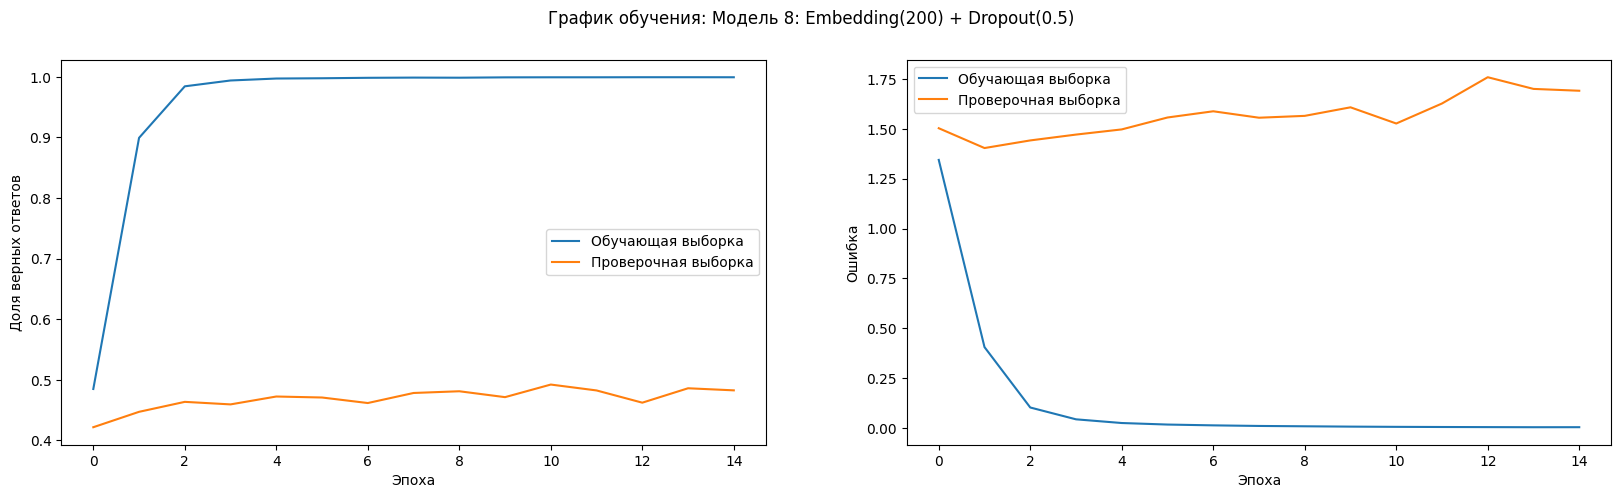

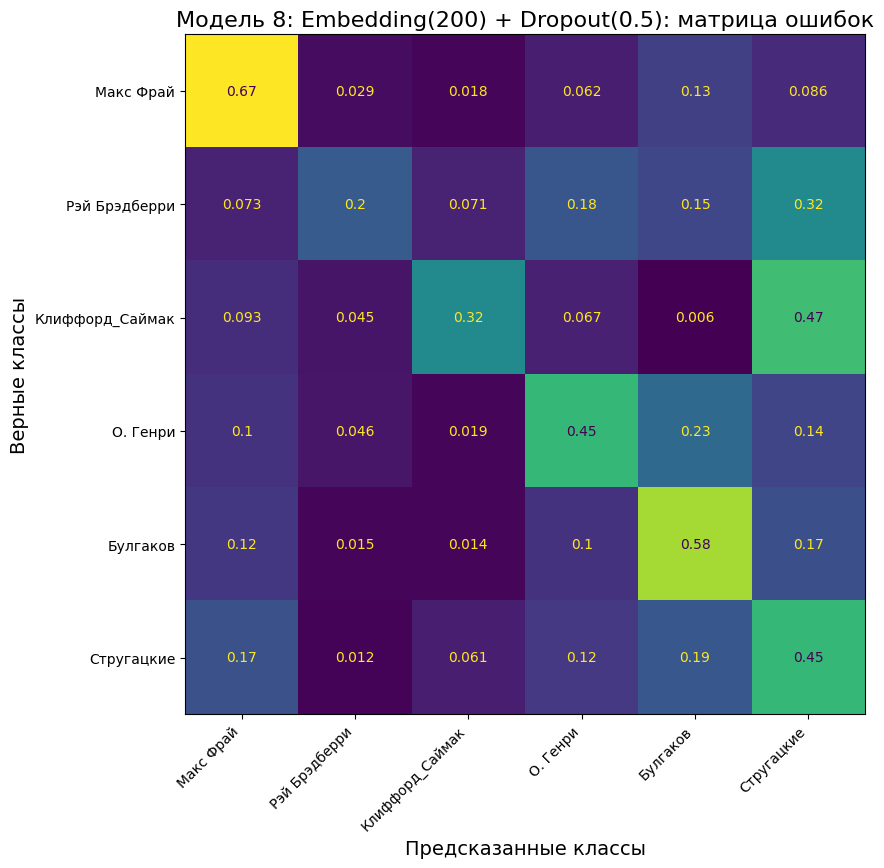

--------------------------------------------------------------------------------
Нейросеть: Модель 8: Embedding(200) + Dropout(0.5)
Класс: Макс Фрай             67% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         32% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       47% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: О. Генри              45% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              58% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            45% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 44.6%


In [ ]:
class Model8_Emb(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, 200)
        self.spatial_dropout = nn.Dropout2d(0.4)
        self.bn1 = nn.BatchNorm1d(WIN_SIZE * 200)
        self.fc1 = nn.Linear(WIN_SIZE * 200, 200)
        self.dropout = nn.Dropout(0.5)
        self.bn2 = nn.BatchNorm1d(200)
        self.fc2 = nn.Linear(200, CLASS_COUNT)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.spatial_dropout(x)
        x = x.permute(0, 2, 1)
        x = x.reshape(x.size(0), -1)
        x = self.bn1(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.bn2(x)
        x = self.fc2(x)
        return x

model_8 = Model8_Emb()
acc_8 = train_eval(model_8, train_loader_emb, test_loader_emb,
                   title='Модель 8: Embedding(200) + Dropout(0.5)', epochs=15)
results['Модель 8: Embedding(200) + Dropout(0.5)'] = acc_8

## Модель 9: Embedding(200) + Flatten без Dropout (только BN)


Модель 9: Embedding(200) без Dropout
Model9_Emb(
  (embedding): Embedding(15000, 200)
  (bn1): BatchNorm1d(200000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=200000, out_features=200, bias=True)
  (bn2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=6, bias=True)
)
Эпоха 1/15: loss=1.1780, acc=0.5703, val_loss=1.4959, val_acc=0.4481
Эпоха 2/15: loss=0.0789, acc=0.9963, val_loss=1.4683, val_acc=0.4943
Эпоха 3/15: loss=0.0061, acc=1.0000, val_loss=1.6145, val_acc=0.4834
Эпоха 4/15: loss=0.0029, acc=1.0000, val_loss=1.5877, val_acc=0.4969
Эпоха 5/15: loss=0.0018, acc=1.0000, val_loss=1.6292, val_acc=0.4981
Эпоха 6/15: loss=0.0012, acc=1.0000, val_loss=1.6534, val_acc=0.4991
Эпоха 7/15: loss=0.0009, acc=1.0000, val_loss=1.6782, val_acc=0.5018
Эпоха 8/15: loss=0.0007, acc=1.0000, val_loss=1.7414, val_acc=0.4954
Эпоха 9/15: loss=0.0005, acc=1.0000, val_loss=1.715

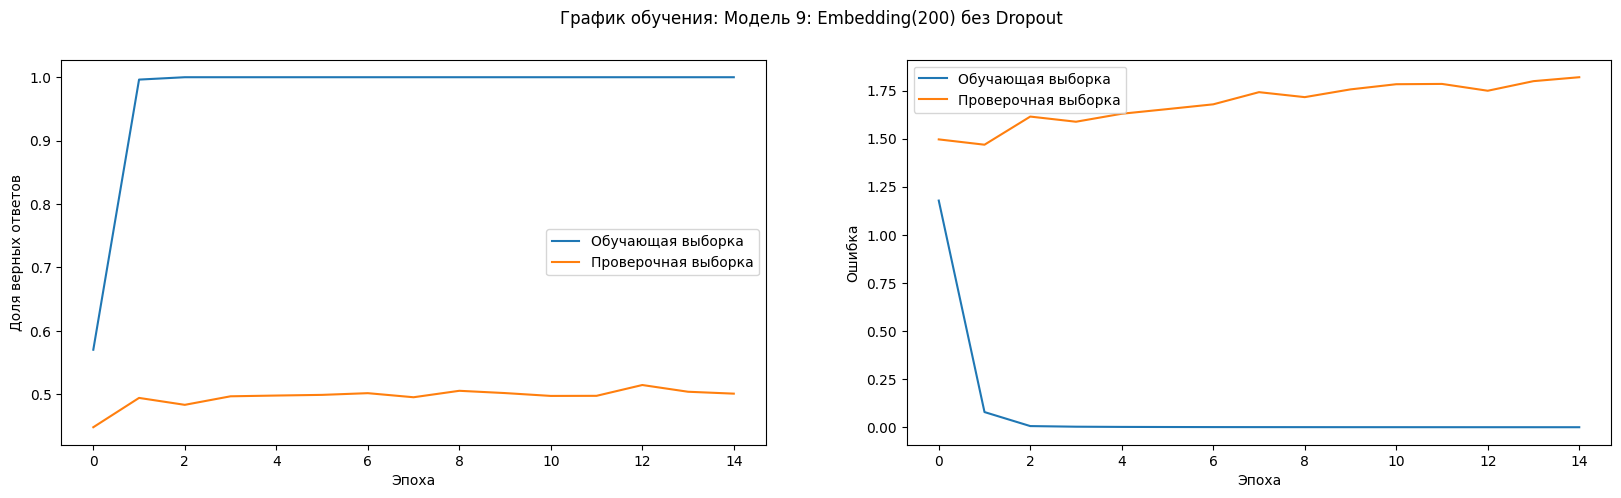

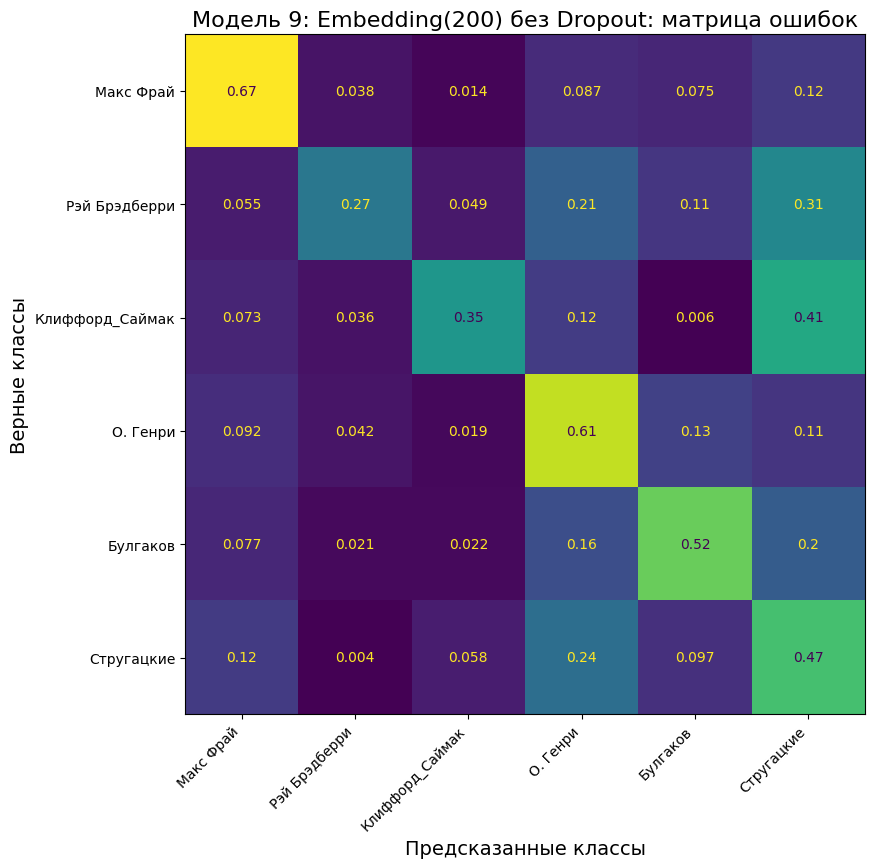

--------------------------------------------------------------------------------
Нейросеть: Модель 9: Embedding(200) без Dropout
Класс: Макс Фрай             67% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         31% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       41% сеть отнесла к классу Стругацкие           - НЕВЕРНО :-(
Класс: О. Генри              61% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Булгаков              52% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Стругацкие            47% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания: 48.2%


In [ ]:
class Model9_Emb(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, 200)
        self.bn1 = nn.BatchNorm1d(WIN_SIZE * 200)
        self.fc1 = nn.Linear(WIN_SIZE * 200, 200)
        self.bn2 = nn.BatchNorm1d(200)
        self.fc2 = nn.Linear(200, CLASS_COUNT)

    def forward(self, x):
        x = self.embedding(x)
        x = x.reshape(x.size(0), -1)
        x = self.bn1(x)
        x = torch.relu(self.fc1(x))
        x = self.bn2(x)
        x = self.fc2(x)
        return x

model_9 = Model9_Emb()
acc_9 = train_eval(model_9, train_loader_emb, test_loader_emb,
                   title='Модель 9: Embedding(200) без Dropout', epochs=15)
results['Модель 9: Embedding(200) без Dropout'] = acc_9

# Итоги: сравнение всех 9 моделей

In [ ]:
# Сводная таблица
print('СВОДНАЯ ТАБЛИЦА ТОЧНОСТИ ВСЕХ 9 МОДЕЛЕЙ (PyTorch)')
for name, acc in results.items():
    print(f'{name:<50} → {acc:5.1f}%')

best_name = max(results, key=results.get)
print(f'\n Лучшая модель: {best_name}')
print(f'   Точность: {results[best_name]:.1f}%')

СВОДНАЯ ТАБЛИЦА ТОЧНОСТИ ВСЕХ 9 МОДЕЛЕЙ (PyTorch)
Модель 1: BoW Dense(200)                           →  91.5%
Модель 2: BoW Dense(400)                           →  90.7%
Модель 3: BoW Dense(300→100)                       →  88.9%
Модель 4: BoW Dense(500→200→50)                    →  91.4%
Модель 5: Embedding(20) + Flatten                  →  38.2%
Модель 6: Embedding(50) + Flatten                  →  38.4%
Модель 7: Embedding(100) + Flatten                 →  39.6%
Модель 8: Embedding(200) + Dropout(0.5)            →  44.6%
Модель 9: Embedding(200) без Dropout               →  48.2%

 Лучшая модель: Модель 1: BoW Dense(200)
   Точность: 91.5%


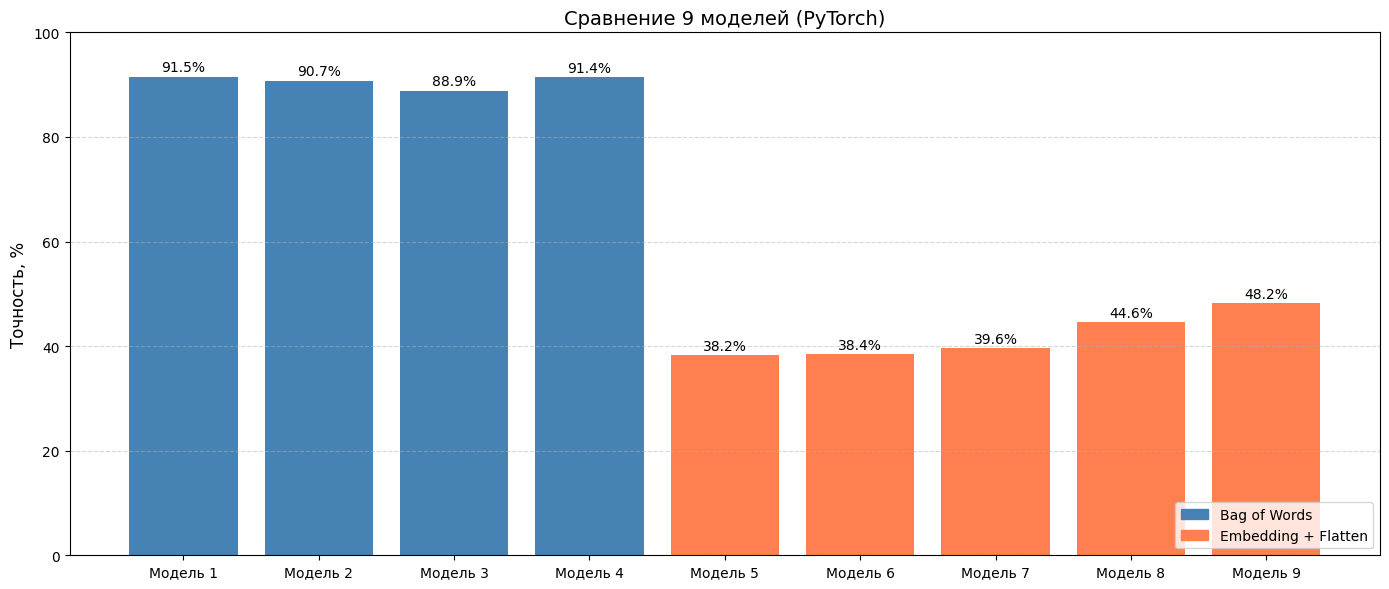

In [ ]:
# Визуализация сравнения
fig, ax = plt.subplots(figsize=(14, 6))
short_names = [f'Модель {i+1}' for i in range(len(results))]
values = list(results.values())
colors = ['steelblue']*4 + ['coral']*5

bars = ax.bar(short_names, values, color=colors)
ax.set_ylabel('Точность, %', fontsize=12)
ax.set_title('Сравнение 9 моделей (PyTorch)', fontsize=14)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)

# Легенда
import matplotlib.patches as mpatches
legend_elems = [
    mpatches.Patch(color='steelblue', label='Bag of Words'),
    mpatches.Patch(color='coral', label='Embedding + Flatten')
]
ax.legend(handles=legend_elems, loc='lower right')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()